In [ ]:
import ast
import optuna
import ipynbname
import pandas as pd
import numpy as np
from optuna.exceptions import TrialPruned
from Functions.AutoCloud_V3 import *
from Functions.Utils import *
from Functions.Graphs import *
from Functions.TedaGraphs import *
from Functions.Utils_OPT import *

FileName = ipynbname.name()
RS = pd.read_excel(r'Dataset\RS.xlsx')
HI = pd.read_csv(r'Dataset\Bearing1_1.csv')
sig = HI['PC1'].values

In [ ]:
params =  [2.0, 5, [58, 11, 64, 31, 32], 15, 5, [1,1,1], 10,'ahead', 'tanh']

m,nI,nR,nO,mO,ηS,τ,mode,act = params
if isinstance(nR, str): nR = ast.literal_eval(nR)
X, Y, Z = PrepareData(RS, HI, nI, nO, mO, 1, mode)

teda=AutoCloud(m=m,nI=len(Y[0]),nR=nR,nO=nO+mO,ηS=ηS,mode=mode,act=act,
               tau=τ,rho=0.001,eol=0.3,ref=len(sig)-nI+1,wtaG=False,wtaP=True) 

for j,_ in enumerate(X[:]):
    
    teda.run(X[j])
    teda.RUL_Prediction(Y[j],mode='interval',lim=len(sig)-nI+1,show=False)
    teda.WAPE_HI2(Y[j],Z[j])
    teda.Adapt(Y[j],Z[j])
    

#teda.c = np.append(teda.c,teda.gm)  
PlotDSI_3D_PLT(teda)


In [ ]:
print(xxxx)

In [ ]:
def Optimize(
        FileName=None,OptDim=None,OptSampler=None,OptSeed=None,OptPrune=False,
        n_study=None,timeout=None,n_trials=None,
        patience=None,
        mS =None,nIS=None,nLS=None,nRS=None,nOS =None,mOS=None,
        N1S=None,N2S=None,N3S=None,τS =None,mdS=None,actS=None):

    '''
        OptSampler modes available: None, Auto, GP, NSGAII, Random, TPE
    
        None: sampler default, suport multivariate optimization

        GP: suport multivariate optimization

        Auto: suport multivariate optimization
        
        NSGAII: poorly suport multivariate optimization
        
        Random: poorly suport multivariate optimization

        TPE: suport multivariate optimization
    '''

    if OptDim == 1 or OptDim is None: SingleObj = True
    elif OptDim > 1: SingleObj = False    
    if n_study is None: n_study = 1
    if timeout is None: timeout = 60
    if n_trials is None and patience is None: 
        n_trials = 25
        patience = 25
    elif n_trials < 100 and patience is None:
        patience = int(0.25*n_trials)
    elif n_trials >= 1e2 and n_trials < 1e3 and patience is None:
        patience = int(0.20*n_trials)
    elif n_trials >= 1e3 and n_trials < 5e3 and patience is None:
        patience = int(0.150*n_trials)
    elif n_trials >= 5e3 and n_trials < 1e4 and patience is None:
        patience = int(0.125*n_trials)    
    elif n_trials >= 1e4 and patience is None:
        patience = int(0.03*n_trials)   

    if mS  is None: mS  = [1.75,4.25]
    if nIS is None: nIS = [2,40]
    if nLS is None: nLS = [1,5]
    if nRS is None: nRS = [1,60]
    if nOS is None: nOS = [1,40]
    if mOS is None: mOS = [0,40]
    if N1S is None: N1S = [1,9]
    if N2S is None: N2S = [1,9]
    if N3S is None: N3S = [1,9]
    if τS  is None: τS  = [1,25]
    if mdS is None: mdS = [0,1]
    if actS is None: actS = [0,1,2]

    if SingleObj: names = ['MAPE_RUL+MAPE_HI', 'm', 'nI', 'nR', 'nO', 'mO', 'N1', 'N2', 'N3','TAU','past/ahead','activation']
    else: names = ['MAPE_RUL','MAPE_HI', 'm', 'nI', 'nR', 'nO', 'mO', 'N1', 'N2', 'N3','TAU','past/ahead','activation']
    study_dir, out_path = df_ParamsTable(names,FileName)

    for i in range(n_study):
        print('iteration:',i+1)
        def objective(trial):
            
            m = trial.suggest_float('m', mS[0], mS[1],step=0.25)
            τ = trial.suggest_int('τ', τS[0], τS[1])
            mode = trial.suggest_int('mode', mdS[0], mdS[1])  
            act = trial.suggest_int('act', actS[0], actS[1])
            N1 = trial.suggest_int('N1', N1S[0], N1S[1])
            N2 = trial.suggest_int('N2', N2S[0], N2S[1])
            N3 = trial.suggest_int('N3', N3S[0], N3S[1])
            nI = trial.suggest_int('nI', nIS[0], nIS[1]) 
            nO = trial.suggest_int('nO', nOS[0], nOS[1]) 
            if mode == 'past' or mode == 0:
                mO = trial.suggest_int('mO', 0, 0) 
                if nO > nI: raise TrialPruned()
            elif mode == 'ahead' or mode == 1:
                mO = trial.suggest_int('mO', mOS[0], mOS[1]) 
                if   nI > 20 or nO > 20: raise TrialPruned()
                elif mO > nI: raise TrialPruned()
            nL = trial.suggest_int('nL', nLS[0], nLS[1])
            nR = [trial.suggest_int(f'nL{l}', nRS[0], nRS[1]) for l in range(nL)]

            X, Y, Z = PrepareData(RS, HI, nI, nO, mO, 1, mode)
            
            teda=AutoCloud(m=m,nI=len(Y[0]),nR=nR,nO=nO+mO,ηS=[N1,N2,N3],mode=mode,act=act,
                           tau=τ,rho=0.0,eol=0.3,ref=len(sig)-nI+1,wtaG=True,wtaP=True) 
            for j,_ in enumerate(X[:]):
                teda.run(X[j])
                teda.RUL_Prediction(Y[j],mode='single',lim=len(sig)-nI+1)
                teda.Adapt(Y[j],Z[j])
                #teda.WAPE_HI2(Y[j],Z[j])

                if np.isinf(teda.hiP[-1]) or np.isnan(teda.hiP[-1]): raise TrialPruned()
                if not OptPrune: continue
        
                if j >=60 and j%5==0:
                    if teda.wape_RUL > 0.6: raise TrialPruned()
                    if teda.wape_HI  > 0.3: raise TrialPruned()

                if SingleObj and j%35==0:
                    trial.report(teda.wape_RUL+teda.wape_HI, j)
                    if trial.should_prune():
                        raise optuna.TrialPruned()

            if SingleObj: return teda.wape_RUL + teda.wape_HI
            else: return teda.wape_RUL,teda.wape_HI

        pruner=optuna.pruners.HyperbandPruner()
        if SingleObj: study = optuna.create_study(direction='minimize',pruner=pruner,sampler=SelSampler(mode=OptSampler,seed=OptSeed))
        else: study = optuna.create_study(directions=['minimize','minimize'],sampler=SelSampler(mode=OptSampler,seed=OptSeed))
        study.optimize(objective, n_trials=n_trials, timeout=timeout, 
                       callbacks=[EarlyStoppingCallback(patience=patience)]
                       )

        vec = []
        if SingleObj:
            trials = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
            for trial in trials:
                p = trial.params
                nR_list = [p[f'nL{l}'] for l in range(p['nL'])]
                row = [trial.values[0],p['m'],p['nI'],str(nR_list),p['nO'],p['mO'],p['N1'],p['N2'],p['N3'],p['τ'],p['mode'],p['act']]   
                vec.append(row)
            df2 = pd.DataFrame(vec,columns=names)
            df2 = df2.sort_values(by=df2.columns[0], ascending=False)[-5:]

        elif not SingleObj: 
            for trial in study.best_trials:
                p = trial.params
                nR_list = [p[f'nL{l}'] for l in range(p['nL'])]
                row = [trial.values[0],trial.values[1],p['m'],p['nI'],str(nR_list),p['nO'],p['mO'],p['N1'],p['N2'],p['N3'],p['τ'],p['mode'],p['act']]
                vec.append(row)
            df2 = pd.DataFrame(vec,columns=names)
        
    if os.path.isfile(out_path) and out_path.startswith(study_dir):
        df1 = pd.read_csv(out_path)
        df_stdy = pd.concat([df1, df2], ignore_index=True)
    
    else: df_stdy = df2
    
    df_stdy = df_stdy.drop_duplicates()
    df_stdy.to_csv(out_path, index=False)

    if not SingleObj: 
        Sum = df_stdy.iloc[:, 0] + df_stdy.iloc[:, 1]
        df_stdy = df_stdy.loc[Sum.sort_values(ascending=False).index]
    elif SingleObj:
        Sum = df_stdy.iloc[:, 0] + 0
        df_stdy = df_stdy.loc[Sum.sort_values(ascending=False).index]
    
    return df_stdy

In [3]:
df = Optimize(FileName=FileName[:-3],OptDim=2,OptSampler='gp',OptPrune=False,
                         n_study=1,timeout=1200,n_trials=50,patience=1e3,
                         mS=[2.0,4.5],nLS=[1,4],nRS=[1,70],mdS=[1,1],actS=[0,0])

BEST TRIAL
Trial #006 | Objetivos: [0.2474, 0.0199] (Soma: 0.2673) | Params: {'m': 4.25, 'τ': 10, 'mode': 1, 'act': 0, 'N1': 1, 'N2': 6, 'N3': 4, 'nI': 16, 'nO': 13, 'mO': 0, 'nL': 2, 'nL0': 40, 'nL1': 60}
-> TOTAL NUMBER OF SOLUTIONS IN THE PARETO FRONT: 1

LAST 3 TRIALS
Trial #047 [COMPLETE] | Score: [0.893, 0.6525] | Params: {'m': 4.0, 'τ': 10, 'mode': 1, 'act': 0, 'N1': 3, 'N2': 6, 'N3': 3, 'nI': 13, 'nO': 11, 'mO': 13, 'nL': 3, 'nL0': 4, 'nL1': 48, 'nL2': 14}
Trial #048 [PRUNED]
Trial #049 [PRUNED]
--------------------------------------------------------------------------------
STOPPING STATUS: 6/1000.0 ITERATIONS WITHOUT IMPROVEMENT.
--------------------------------------------------------------------------------


In [ ]:
for i in range(1,6):
    df = Optimize(FileName=FileName[:-3],OptDim=2,OptSampler=None,OptPrune=False,
                         n_study=1,timeout=600,n_trials=2e3,patience=2e2,
                         mS=[2.0,4.5],nLS=[i,i],nRS=[1,70],mdS=[1,1],actS=[0,1])

BEST TRIAL
Trial #1082 | Objetivos: [0.1766, 0.0226] (Soma: 0.1991) | Params: {'m': 3.25, 'τ': 11, 'mode': 1, 'act': 0, 'N1': 1, 'N2': 9, 'N3': 6, 'nI': 14, 'nO': 3, 'mO': 3, 'nL': 4, 'nL0': 4, 'nL1': 49, 'nL2': 43, 'nL3': 40}
-> TOTAL NUMBER OF SOLUTIONS IN THE PARETO FRONT: 7

LAST 3 TRIALS
Trial #1136 [COMPLETE] | Score: [2.3967, 0.0234] | Params: {'m': 4.0, 'τ': 3, 'mode': 1, 'act': 0, 'N1': 1, 'N2': 4, 'N3': 5, 'nI': 15, 'nO': 7, 'mO': 5, 'nL': 4, 'nL0': 69, 'nL1': 25, 'nL2': 7, 'nL3': 28}
Trial #1137 [COMPLETE] | Score: [1.5127, 241.1597] | Params: {'m': 3.25, 'τ': 16, 'mode': 1, 'act': 1, 'N1': 1, 'N2': 9, 'N3': 5, 'nI': 9, 'nO': 19, 'mO': 3, 'nL': 4, 'nL0': 43, 'nL1': 41, 'nL2': 11, 'nL3': 35}
Trial #1138 [COMPLETE] | Score: [1.6993, 0.0209] | Params: {'m': 3.25, 'τ': 3, 'mode': 1, 'act': 0, 'N1': 1, 'N2': 9, 'N3': 5, 'nI': 11, 'nO': 19, 'mO': 3, 'nL': 4, 'nL0': 36, 'nL1': 20, 'nL2': 43, 'nL3': 9}
--------------------------------------------------------------------------------


In [4]:
params_list = df.values[:,-11:]
df

,MAPE_RUL,MAPE_HI,m,nI,nR,nO,mO,N1,N2,N3,TAU,past/ahead,activation
2,0.967867,1.330687,2.75,16,"[2, 63, 41]",6,7,8,9,9,1,1,0
3,2.035231,0.150062,3.00,11,"[63, 30, 30]",13,4,2,6,8,16,1,0
1,2.099875,0.017423,3.00,14,"[20, 4, 24]",10,2,1,2,3,2,1,0
0,2.068015,0.024271,2.75,5,[18],7,1,1,8,2,9,1,0
4,0.247434,0.019889,4.25,16,"[40, 60]",13,0,1,6,4,10,1,0


In [5]:
tedas = []
for i,params in enumerate(params_list[-1:]):
    m,nI,nR,nO,mO,N1,N2,N3,τ,mode,act = params
    X, Y, Z = PrepareData(RS, HI, nI, nO, mO, 1, mode)
    if isinstance(nR, str): nR = ast.literal_eval(nR)

    teda=AutoCloud(m=m,nI=len(Y[0]),nR=nR,nO=nO+mO,ηS=[N1,N2,N3],mode=mode,act=act,
                tau=τ,rho=0.001,eol=0.3,ref=len(sig)-nI+1,wtaG=True,wtaP=True) 
    for j,_ in enumerate(X[:]):
        teda.run(X[j])
        teda.RUL_Prediction(Y[j],mode='interval',lim=len(sig)-nI+1,show=False)
        teda.Adapt(Y[j],Z[j])

    teda.c = np.append(teda.c,teda.gm)  
    tedas.append(teda)
    #PlotSeriesPLY(ySeries=[teda.wape_HI_hist,teda.wape_RUL_hist])

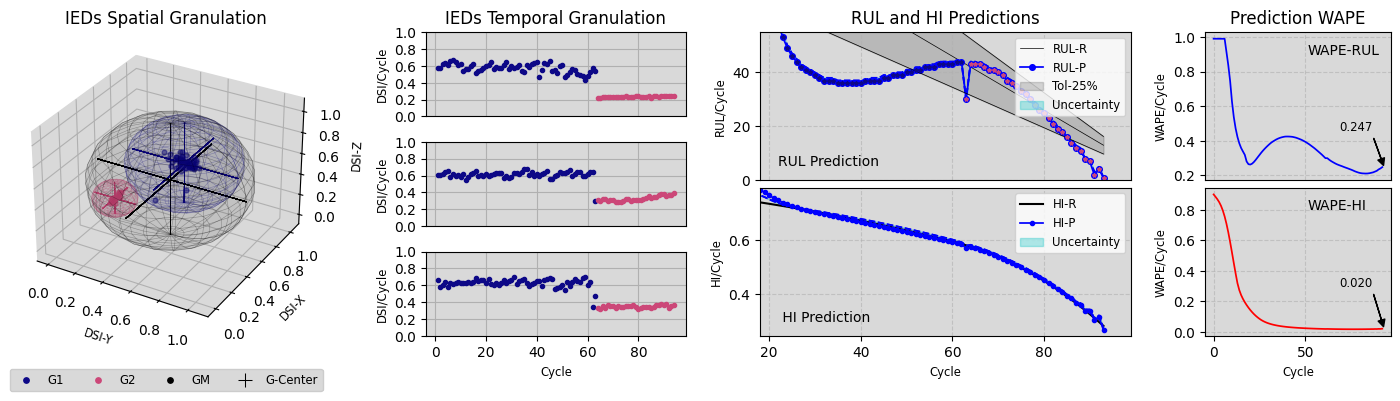

In [6]:
PlotDSI_3D_PLT(tedas[0])

In [ ]:
PlotDSI_3D_PLT(tedas[0])